# Project Impact Evaluation with Monte Carlo Simulation

## Project Context

This notebook reconstructs the impact-simulation idea from the team project while making assumptions and uncertainty explicit. It uses no observed enforcement outcomes. The publication-reported 34.43% reduction is treated as a model estimate, not as an observed or causal effect.

## Research Question

Under the intervention formula documented in the source notebook, what reduction distribution is produced by a reproducible Monte Carlo simulation, and how does that output compare with the publication-reported 34.43% estimate?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_SEED = 2024
N_SIMULATIONS = 10_000
PUBLICATION_REPORTED_REDUCTION_PCT = 34.43

BASELINE_MEAN = 100.0
BASELINE_SD = 20.0
FREQUENCY_OPTIONS = np.array([1, 2, 3])
AREA_OPTIONS = np.array([100.0, 200.0, 300.0])
EFFICIENCY_RANGE = (0.80, 1.00)

FREQUENCY_COEFFICIENT = 0.01
AREA_COEFFICIENT = 0.05
EFFICIENCY_COEFFICIENT = 0.015

sns.set_theme(style="whitegrid", context="notebook")
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Data

This notebook uses synthetic simulation draws only. Baseline event counts, patrol frequency, covered area, and implementation efficiency are assumed inputs. They are not estimates from observed patrol or seizure data.

## Methods

For each paired simulation draw, the baseline event count is sampled from a nonnegative normal distribution. An intervention reduction rate is calculated as:

`0.01 × frequency + 0.05 × log(area + 1) + 0.015 × efficiency`

The intervention event count equals the paired baseline multiplied by one minus that rate. Fixed seeds support reproducibility. The resulting interval is a simulation interval under these assumptions, not a confidence interval for a real population effect.

In [2]:
def simulate_impact(n_simulations=N_SIMULATIONS, seed=RANDOM_SEED):
    # Run the paired illustrative intervention simulation.
    rng = np.random.default_rng(seed)
    baseline_events = np.clip(rng.normal(BASELINE_MEAN, BASELINE_SD, n_simulations), 0, None)
    patrol_frequency = rng.choice(FREQUENCY_OPTIONS, size=n_simulations)
    covered_area = rng.choice(AREA_OPTIONS, size=n_simulations)
    implementation_efficiency = rng.uniform(*EFFICIENCY_RANGE, size=n_simulations)
    reduction_rate = (
        FREQUENCY_COEFFICIENT * patrol_frequency
        + AREA_COEFFICIENT * np.log(covered_area + 1)
        + EFFICIENCY_COEFFICIENT * implementation_efficiency
    )
    intervention_events = baseline_events * (1 - reduction_rate)
    return pd.DataFrame(
        {
            "baseline_events": baseline_events,
            "intervention_events": intervention_events,
            "patrol_frequency": patrol_frequency,
            "covered_area": covered_area,
            "implementation_efficiency": implementation_efficiency,
            "reduction_rate": reduction_rate,
        }
    )

simulation = simulate_impact()
estimated_reduction_pct = 100 * (
    simulation["baseline_events"].mean() - simulation["intervention_events"].mean()
) / simulation["baseline_events"].mean()
interval = 100 * simulation["reduction_rate"].quantile([0.025, 0.975])
difference_pp = estimated_reduction_pct - PUBLICATION_REPORTED_REDUCTION_PCT

result_summary = pd.DataFrame(
    {
        "metric": [
            "Mean baseline events (synthetic)",
            "Mean intervention events (synthetic)",
            "Estimated mean reduction",
            "Lower bound of central 95% simulation interval",
            "Upper bound of central 95% simulation interval",
            "Publication-reported model estimate",
            "Difference from publication estimate",
        ],
        "value": [
            simulation["baseline_events"].mean(),
            simulation["intervention_events"].mean(),
            estimated_reduction_pct,
            interval.iloc[0],
            interval.iloc[1],
            PUBLICATION_REPORTED_REDUCTION_PCT,
            difference_pp,
        ],
        "unit": ["events", "events", "%", "%", "%", "%", "percentage points"],
    }
)
display(result_summary.round(2))

,metric,value,unit
0,Mean baseline events (synthetic),100.16,events
1,Mean intervention events (synthetic),70.71,events
2,Estimated mean reduction,29.40,%
3,Lower bound of central 95% simulation interval,25.34,%
4,Upper bound of central 95% simulation interval,32.97,%
5,Publication-reported model estimate,34.43,%
6,Difference from publication estimate,-5.03,percentage points


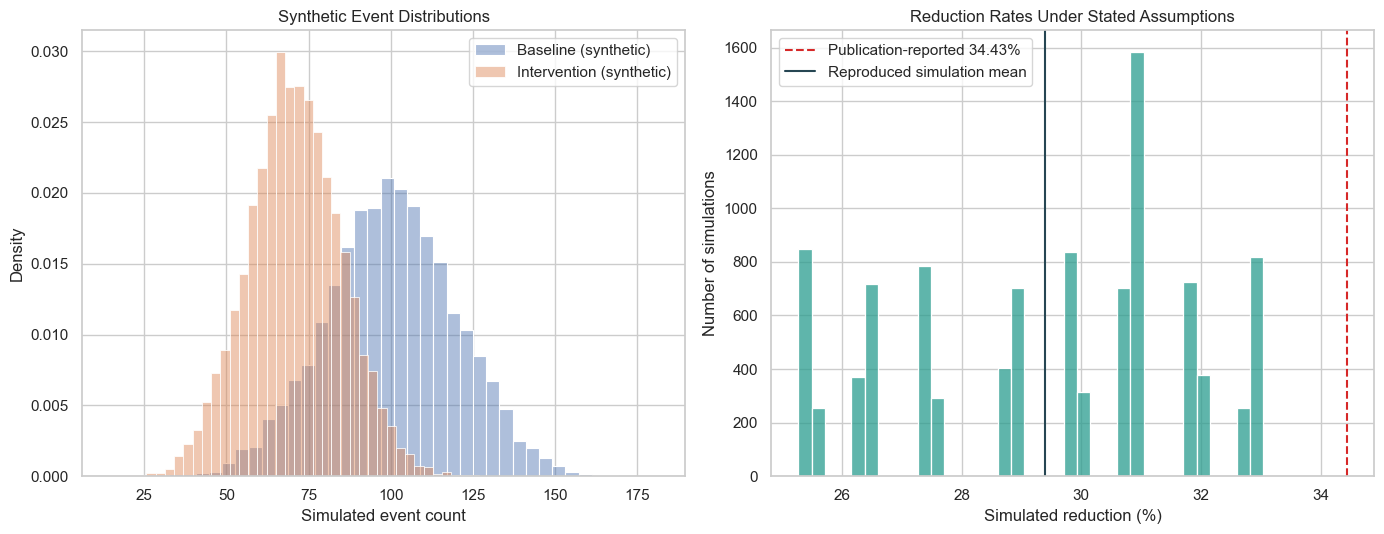

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.histplot(simulation["baseline_events"], bins=40, stat="density", alpha=0.45, label="Baseline (synthetic)", ax=axes[0])
sns.histplot(simulation["intervention_events"], bins=40, stat="density", alpha=0.45, label="Intervention (synthetic)", ax=axes[0])
axes[0].set_title("Synthetic Event Distributions")
axes[0].set_xlabel("Simulated event count")
axes[0].set_ylabel("Density")
axes[0].legend()

sns.histplot(100 * simulation["reduction_rate"], bins=35, color="#2a9d8f", ax=axes[1])
axes[1].axvline(PUBLICATION_REPORTED_REDUCTION_PCT, color="#d62828", linestyle="--", label="Publication-reported 34.43%")
axes[1].axvline(estimated_reduction_pct, color="#264653", linestyle="-", label="Reproduced simulation mean")
axes[1].set_title("Reduction Rates Under Stated Assumptions")
axes[1].set_xlabel("Simulated reduction (%)")
axes[1].set_ylabel("Number of simulations")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_impact_simulation_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

## Methods: Sensitivity Analysis

The deterministic formula is evaluated over the documented patrol-frequency and area options at three efficiency levels. This shows how assumptions drive the model output; it is not empirical evidence that changing these inputs would cause the displayed effect.

,patrol_frequency,covered_area,implementation_efficiency,modeled_reduction_pct
0,1,100.0,0.8,25.28
1,1,100.0,0.9,25.43
2,1,100.0,1.0,25.58
3,1,200.0,0.8,28.72
4,1,200.0,0.9,28.87
5,1,200.0,1.0,29.02
6,1,300.0,0.8,30.74
7,1,300.0,0.9,30.89
8,1,300.0,1.0,31.04
9,2,100.0,0.8,26.28


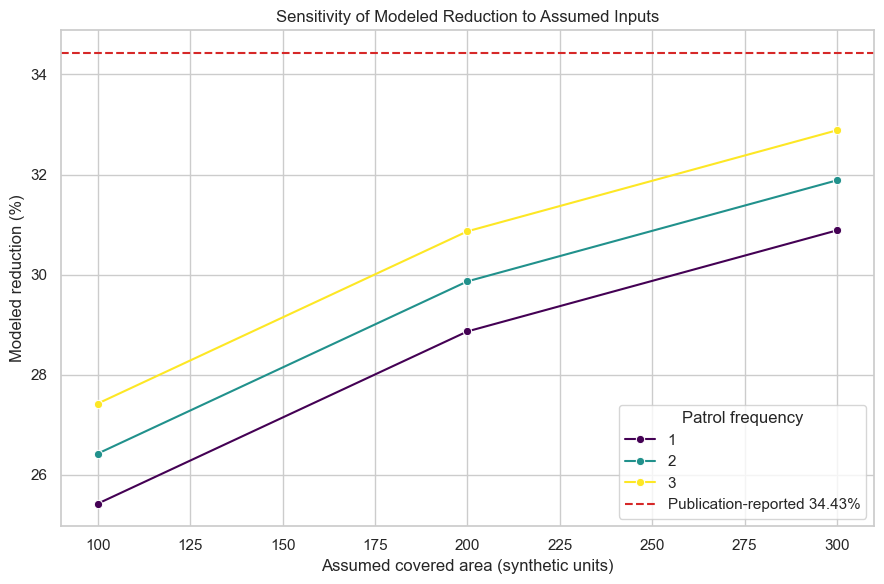

In [4]:
sensitivity_rows = []
for frequency in FREQUENCY_OPTIONS:
    for area in AREA_OPTIONS:
        for efficiency in [0.80, 0.90, 1.00]:
            reduction = 100 * (
                FREQUENCY_COEFFICIENT * frequency
                + AREA_COEFFICIENT * np.log(area + 1)
                + EFFICIENCY_COEFFICIENT * efficiency
            )
            sensitivity_rows.append(
                {
                    "patrol_frequency": frequency,
                    "covered_area": area,
                    "implementation_efficiency": efficiency,
                    "modeled_reduction_pct": reduction,
                }
            )
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(2))

fig, ax = plt.subplots(figsize=(9, 6))
middle_efficiency = sensitivity.loc[sensitivity["implementation_efficiency"].eq(0.90)]
sns.lineplot(
    data=middle_efficiency,
    x="covered_area",
    y="modeled_reduction_pct",
    hue="patrol_frequency",
    marker="o",
    palette="viridis",
    ax=ax,
)
ax.axhline(PUBLICATION_REPORTED_REDUCTION_PCT, color="#d62828", linestyle="--", label="Publication-reported 34.43%")
ax.set_title("Sensitivity of Modeled Reduction to Assumed Inputs")
ax.set_xlabel("Assumed covered area (synthetic units)")
ax.set_ylabel("Modeled reduction (%)")
ax.legend(title="Patrol frequency")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_impact_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

In [5]:
direction = "above" if difference_pp > 0 else "below"
print(
    f"Under the implemented assumptions, the estimated mean reduction is {estimated_reduction_pct:.2f}%, "
    f"which is {abs(difference_pp):.2f} percentage points {direction} the publication-reported 34.43%."
)
print(
    "Because the source materials do not provide sufficient parameter provenance or outcome data, "
    "this simulation does not independently reproduce or validate the 34.43% estimate."
)

Under the implemented assumptions, the estimated mean reduction is 29.40%, which is 5.03 percentage points below the publication-reported 34.43%.
Because the source materials do not provide sufficient parameter provenance or outcome data, this simulation does not independently reproduce or validate the 34.43% estimate.


## Results

The executed summary reports the result produced by the documented formula and fixed simulation settings. It intentionally preserves any difference from the publication-reported 34.43% rather than adjusting parameters to force agreement.

## Limitations

- Inputs and event counts are synthetic.
- Coefficients are assumptions recovered from source code, not validated causal parameters.
- The simulation omits confounding, behavioral adaptation, measurement error, implementation cost, and ecological outcomes.
- The central 95% simulation interval describes modeled draws, not uncertainty about a real-world causal effect.
- The publication-reported 34.43% estimate cannot be independently reproduced from the supplied materials.

## Takeaways

This notebook demonstrates transparent, paired Monte Carlo evaluation and sensitivity analysis. It does not establish that the intervention caused a reduction, and its results should not be used directly for law-enforcement, conservation, or policy decisions without real outcome data and external validation.